In [1]:
import os
##os.chdir('/Users/taruni/Desktop/virality-prediction-ml-2026')
print('Working directory:', os.getcwd())

Working directory: /Users/taruni/Desktop/virality-prediction-ml-2026/notebooks


# 03 — Modeling
Train and compare: Logistic Regression, KNN, SVM, Decision Tree, Random Forest, XGBoost

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings

## ======================Jathin=====================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
##========================Jathin========================

# Load master dataset
master_df = pd.read_csv('data/processed/master.csv')
print('Loaded:', master_df.shape)
print('Viral %:', master_df['viral'].mean().round(3))

Loaded: (90032, 35)
Viral %: 0.2


In [3]:
# Fix day_of_week — convert string days to numbers
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}

master_df['day_of_week'] = master_df['day_of_week'].map(day_map).fillna(master_df['day_of_week'])
master_df['day_of_week'] = pd.to_numeric(master_df['day_of_week'], errors='coerce').fillna(0).astype(int)

print('day_of_week sample:', master_df['day_of_week'].unique()[:10])

day_of_week sample: [5 4 3 1 6 0 2]


In [4]:
# ── TRAIN/TEST SPLIT ──

# Features = everything except viral and engagement_rate
# (engagement_rate would be cheating — it's how we defined viral!)
X = master_df.drop(columns=['viral', 'engagement_rate'])
y = master_df['viral']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print('Training set:', X_train.shape)
print('Test set:    ', X_test.shape)
print()
print('Viral % in train:', y_train.mean().round(3))
print('Viral % in test: ', y_test.mean().round(3))

Training set: (72025, 33)
Test set:     (18007, 33)

Viral % in train: 0.2
Viral % in test:  0.2


In [5]:
# ── MODEL 1: LOGISTIC REGRESSION (baseline) ──
print("Training Logistic Regression...")

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, lr_preds, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

Training Logistic Regression...

--- Logistic Regression Results ---
              precision    recall  f1-score   support

   Not Viral       0.80      1.00      0.89     14413
       Viral       0.00      0.00      0.00      3594

    accuracy                           0.80     18007
   macro avg       0.40      0.50      0.44     18007
weighted avg       0.64      0.80      0.71     18007

ROC-AUC: 0.6089


In [6]:
# ── MODEL 1 FIXED: LOGISTIC REGRESSION with class balancing ──
print("Training Logistic Regression (balanced)...")

lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, lr_preds, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

Training Logistic Regression (balanced)...

--- Logistic Regression Results ---
              precision    recall  f1-score   support

   Not Viral       0.83      0.53      0.65     14413
       Viral       0.23      0.57      0.33      3594

    accuracy                           0.54     18007
   macro avg       0.53      0.55      0.49     18007
weighted avg       0.71      0.54      0.59     18007

ROC-AUC: 0.6084


In [7]:
# ── MODEL 2: KNN ──
print("Training KNN...")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
knn_proba = knn.predict_proba(X_test)[:, 1]

print("\n--- KNN Results ---")
print(classification_report(y_test, knn_preds, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC: {roc_auc_score(y_test, knn_proba):.4f}")

Training KNN...

--- KNN Results ---
              precision    recall  f1-score   support

   Not Viral       0.86      0.95      0.91     14413
       Viral       0.68      0.38      0.49      3594

    accuracy                           0.84     18007
   macro avg       0.77      0.67      0.70     18007
weighted avg       0.82      0.84      0.82     18007

ROC-AUC: 0.7587


In [8]:
# ── MODEL 3: SVM ──
print("Training SVM... (this will take a few minutes)")

svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
svm_proba = svm.predict_proba(X_test)[:, 1]

print("\n--- SVM Results ---")
print(classification_report(y_test, svm_preds, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC: {roc_auc_score(y_test, svm_proba):.4f}")

Training SVM... (this will take a few minutes)

--- SVM Results ---
              precision    recall  f1-score   support

   Not Viral       0.87      0.52      0.65     14413
       Viral       0.26      0.70      0.38      3594

    accuracy                           0.55     18007
   macro avg       0.57      0.61      0.52     18007
weighted avg       0.75      0.55      0.60     18007

ROC-AUC: 0.6586


In [9]:
# ── MODEL 4: DECISION TREE ──
print("Training Decision Tree...")

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    class_weight='balanced'
)

dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print("\n--- Decision Tree Results ---")
print(classification_report(y_test, dt_preds, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC: {roc_auc_score(y_test, dt_proba):.4f}")

Training Decision Tree...

--- Decision Tree Results ---
              precision    recall  f1-score   support

   Not Viral       0.93      0.30      0.46     14413
       Viral       0.25      0.91      0.39      3594

    accuracy                           0.42     18007
   macro avg       0.59      0.61      0.42     18007
weighted avg       0.80      0.42      0.44     18007

ROC-AUC: 0.6818


In [10]:
# ── MODEL 5: RANDOM FOREST ──
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("\n--- Random Forest Results ---")
print(classification_report(y_test, rf_preds, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

Training Random Forest...

--- Random Forest Results ---
              precision    recall  f1-score   support

   Not Viral       0.88      0.88      0.88     14413
       Viral       0.53      0.53      0.53      3594

    accuracy                           0.81     18007
   macro avg       0.71      0.71      0.71     18007
weighted avg       0.81      0.81      0.81     18007

ROC-AUC: 0.8028


In [11]:
# ── MODEL 6: XGBOOST ──
print("Training XGBoost...")

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("\n--- XGBoost Results ---")
print(classification_report(y_test, xgb_preds, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

Training XGBoost...

--- XGBoost Results ---
              precision    recall  f1-score   support

   Not Viral       0.82      1.00      0.90     14413
       Viral       0.92      0.11      0.20      3594

    accuracy                           0.82     18007
   macro avg       0.87      0.56      0.55     18007
weighted avg       0.84      0.82      0.76     18007

ROC-AUC: 0.7321


In [14]:
import pickle
pickle.dump(dt,  open('data/processed/model_dt.pkl', 'wb'))
pickle.dump(rf,  open('data/processed/model_rf.pkl', 'wb'))
pickle.dump(xgb, open('data/processed/model_xgb.pkl', 'wb'))
print('Jathin models saved!')


Jathin models saved!


In [15]:
import os
print(os.getcwd())
print(os.listdir('data/processed/'))

/Users/taruni/Desktop/virality-prediction-ml-2026/notebooks
['scaler.pkl', 'model_lr.pkl', 'model_knn.pkl', 'model_svm.pkl', 'model_rf.pkl', 'master.csv', 'model_dt.pkl', 'model_xgb.pkl']


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/feature_importance_rf.png'

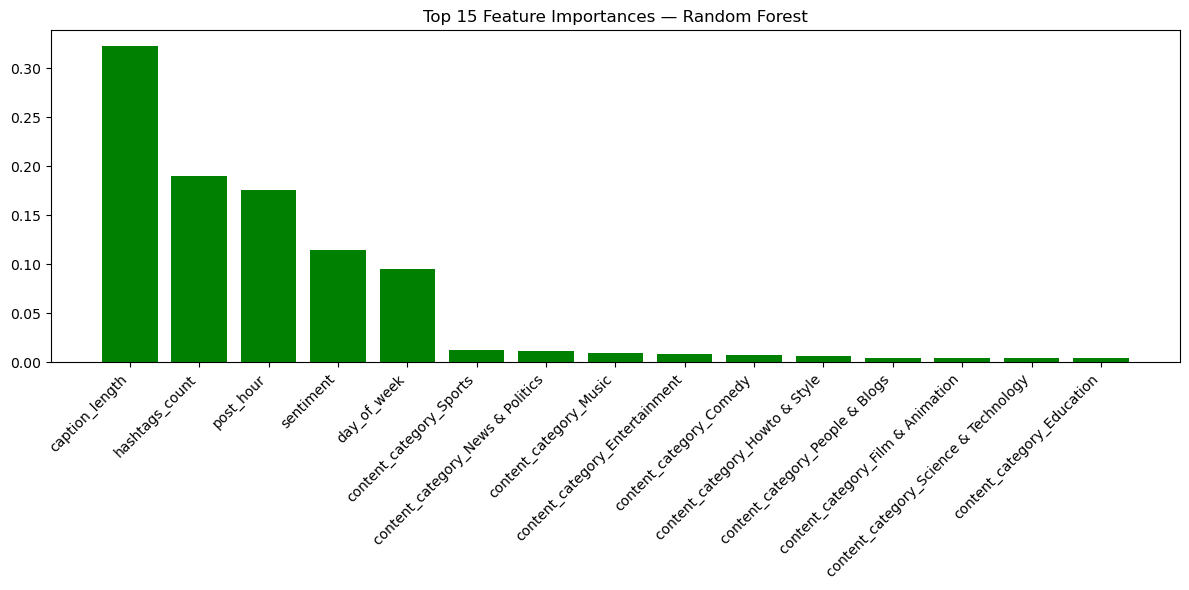

In [16]:
# ── FEATURE IMPORTANCE — RANDOM FOREST ──
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

feature_names = pd.read_csv('data/processed/master.csv').drop(columns=['viral', 'engagement_rate']).columns.tolist()

# Random Forest importances
rf_importances = rf.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1][:15]  # top 15

plt.figure(figsize=(12, 6))
plt.title('Top 15 Feature Importances — Random Forest')
plt.bar(range(15), rf_importances[rf_indices], color='green')
plt.xticks(range(15), [feature_names[i] for i in rf_indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('notebooks/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')